In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.08696760925352573, 0.9732571428571428)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.29390251868367195, 0.904)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.975673
automobile    0.985322
bird          0.970848
cat           0.943485
deer          0.975465
dog           0.948393
frog          0.985728
horse         0.976077
ship          0.987972
truck         0.982754
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 4]

In [17]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)

                    else:
                        indexT.append(idx.cpu().numpy().item())  


                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [6,4,7,2]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [6,4,7,2]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(20975, 28017)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(5994, 7997)

In [20]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [21]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [22]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [23]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.03553130264452525,train_accu=0.9896
Epoch=0,valid_loss=0.09283355551287532,valid_accu=0.9662
0
Epoch=1,train_loss=0.028574635855906777,train_accu=0.9914
Epoch=1,valid_loss=0.09107594045363367,valid_accu=0.9682
0
Epoch=2,train_loss=0.026026952519054923,train_accu=0.9924
Epoch=2,valid_loss=0.0894820799889043,valid_accu=0.9682
Epoch=3,train_loss=0.023895094588292497,train_accu=0.9928285714285714
Epoch=3,valid_loss=0.09006530583389104,valid_accu=0.969
0
Epoch=4,train_loss=0.022941011590563824,train_accu=0.9929428571428571
Epoch=4,valid_loss=0.09110390036720782,valid_accu=0.9694
0
Epoch=5,train_loss=0.021785728650752987,train_accu=0.9934857142857143
Epoch=5,valid_loss=0.09110681905467063,valid_accu=0.9698
0
Epoch=6,train_loss=0.020799371455370315,train_accu=0.9934571428571428
Epoch=6,valid_loss=0.09016350915106014,valid_accu=0.9701
0
Epoch=7,train_loss=0.0198037776798409,train_accu=0.9942571428571428
Epoch=7,valid_loss=0.09227855353513732,valid_accu=0.9696
Epoch=8,train

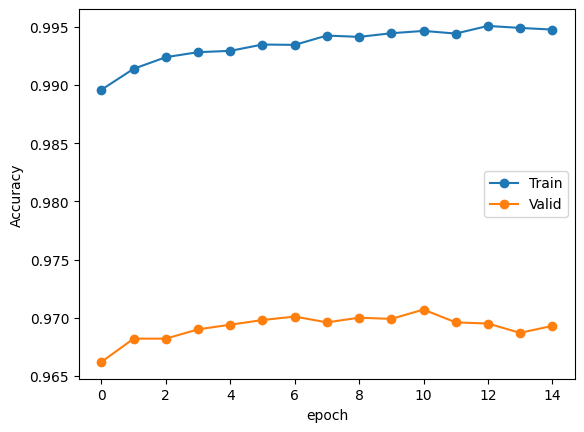

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

In [25]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.033806703053979925,train_accu=0.9899346825141878
Epoch=0,valid_loss=0.18748838327684386,valid_accu=0.9431036638739527
0
Epoch=1,train_loss=0.03285131158362907,train_accu=0.9890780597494379
Epoch=1,valid_loss=0.2321375491740656,valid_accu=0.9372264599224709
Epoch=2,train_loss=0.020343704270491134,train_accu=0.9935753292643752
Epoch=2,valid_loss=0.22256903042901496,valid_accu=0.9384769288483181
Epoch=3,train_loss=0.012117245157874783,train_accu=0.996180890173823
Epoch=3,valid_loss=0.21987970130688342,valid_accu=0.9442290859072152
0
Epoch=4,train_loss=0.009501832221701602,train_accu=0.9980725987793125
Epoch=4,valid_loss=0.23093706634367528,valid_accu=0.9388520695260723
Epoch=5,train_loss=0.015449237848803555,train_accu=0.9948602634115001
Epoch=5,valid_loss=0.2622033113196976,valid_accu=0.9378516943853945
Epoch=6,train_loss=0.006920859862436364,train_accu=0.997894135703323
Epoch=6,valid_loss=0.2644462426363904,valid_accu=0.9408528198074277
Epoch=7,train_loss=0.00387816

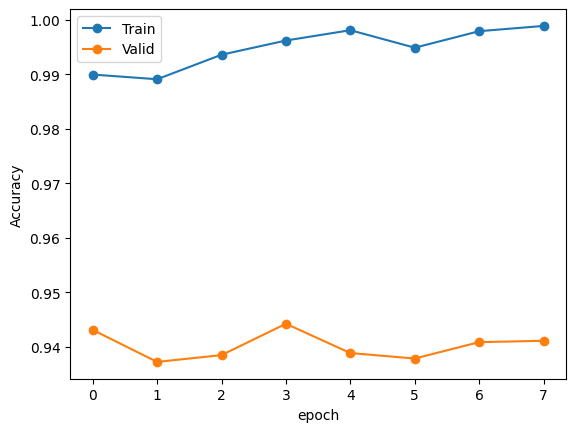

In [26]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.06518178819952904,train_accu=0.9790703218116805
Epoch=0,valid_loss=0.32437468230386235,valid_accu=0.8963963963963963
0
Epoch=1,train_loss=0.04421200388094523,train_accu=0.9878903456495829
Epoch=1,valid_loss=0.3295863276732228,valid_accu=0.9022355689022356
0
Epoch=2,train_loss=0.03241738475883586,train_accu=0.9910369487485101
Epoch=2,valid_loss=0.3302330136259357,valid_accu=0.9030697364030698
0
Epoch=3,train_loss=0.02219247826340656,train_accu=0.9953277711561382
Epoch=3,valid_loss=0.32647745788326094,valid_accu=0.9062395729062396
0
Epoch=4,train_loss=0.015160820356529112,train_accu=0.9959475566150179
Epoch=4,valid_loss=0.3784558844588222,valid_accu=0.9035702369035702
Epoch=5,train_loss=0.012609841132312302,train_accu=0.9971871275327772
Epoch=5,valid_loss=0.35441602911324077,valid_accu=0.9039039039039038
Epoch=6,train_loss=0.008187323538481044,train_accu=0.9978069129916567
Epoch=6,valid_loss=0.408875793860004,valid_accu=0.9049049049049049
Epoch=7,train_loss=0.0079401

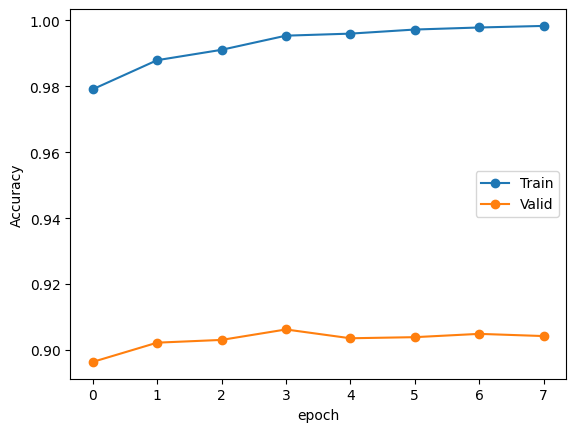

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.018602653221307056, 0.9946571428571429)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.09307504102336243, 0.9707)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.01241210853562999, 0.9962165827890209)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.022200729546089423, 0.9946603098927295)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.2232278267298559, 0.9431036638739527)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.32269033088579074, 0.9067400734067401)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.017974950449727474, 0.9952, 13948)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.27376323024854066, 0.9237, 4046)

In [36]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.04010848344591047, 0.9941142857142857, 13900, 21100)

In [37]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.40642562822327016, 0.9168, 4012, 5988)

In [38]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [39]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.086968,0.973257,0.293903,0.904000
1,Model_Decision,0.018603,0.994657,0.093075,0.970700
2,Model_T,0.012412,0.996217,0.223228,0.943104
3,Model_F,0.022201,0.994660,0.322690,0.906740
4,Total_Model,0.040108,0.994114,0.406426,0.916800
5,Total_Model_without_decision,0.017975,0.995200,0.273763,0.923700


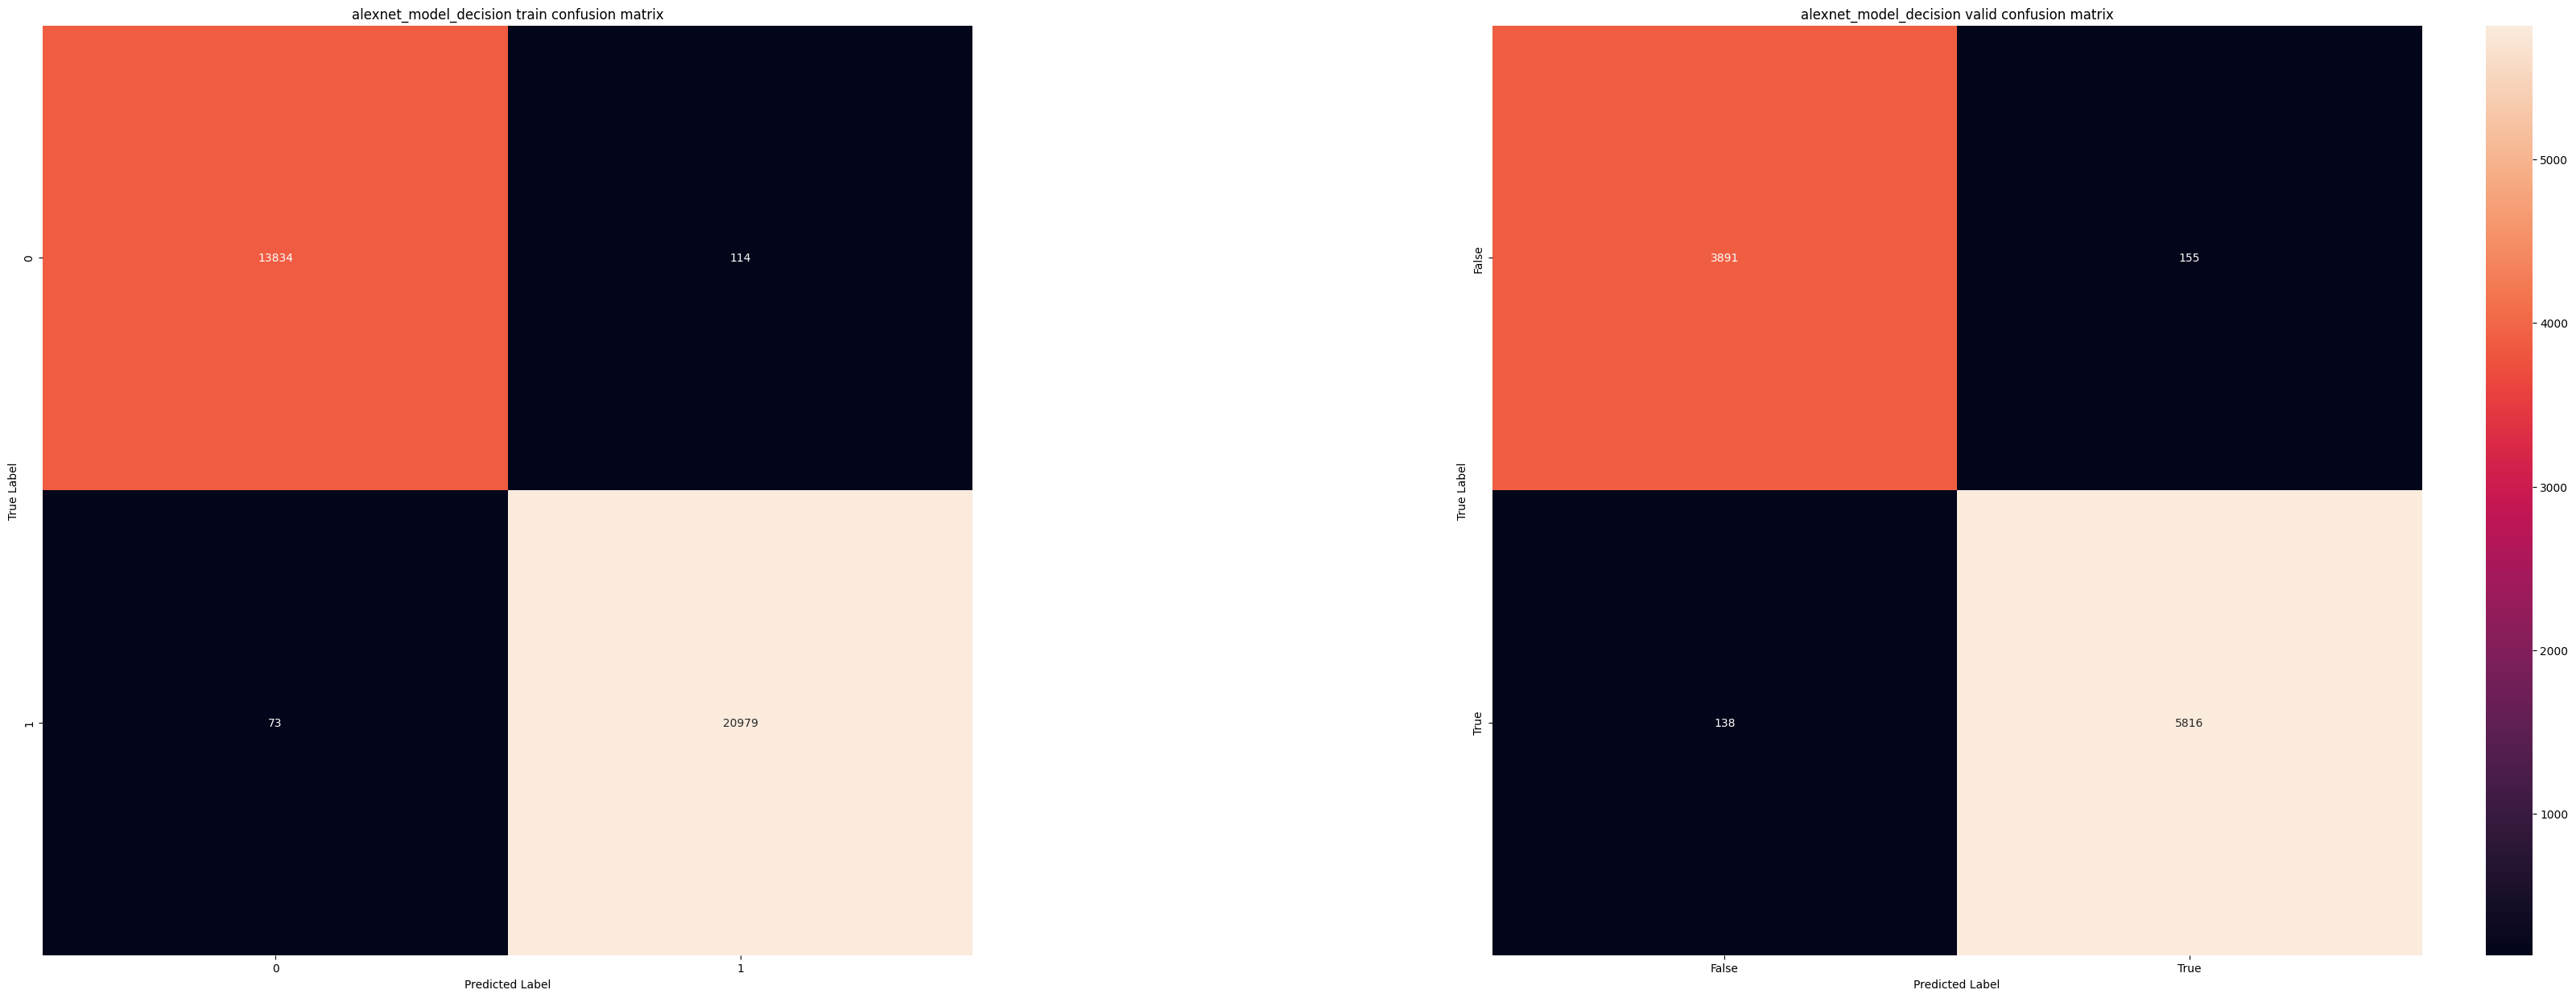

In [40]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

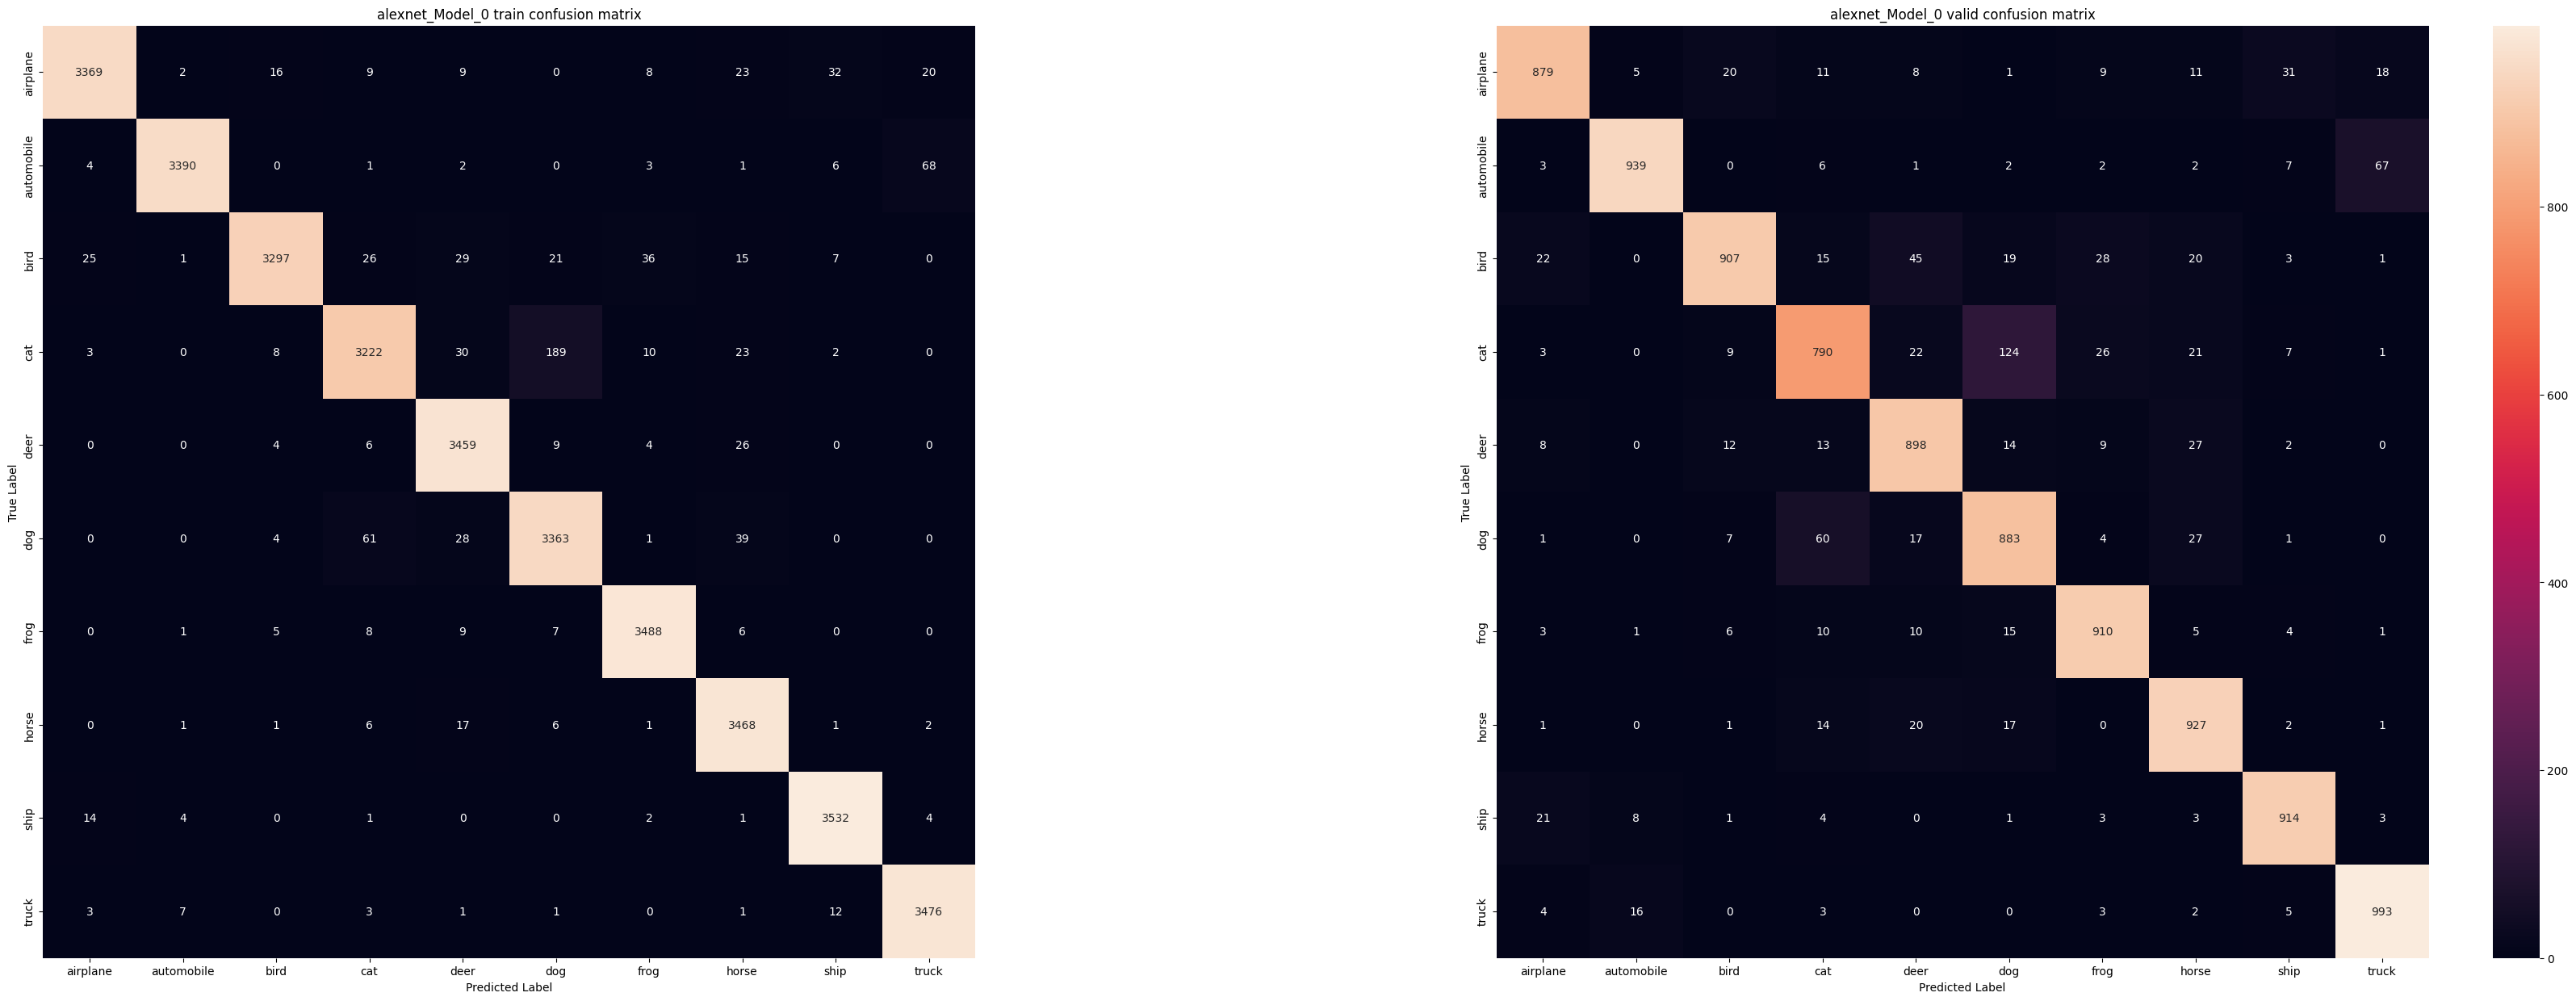

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [42]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [43]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.07164983 0.02156606 0.01310911 0.01286842 0.01226461 0.0118325
 0.01181886 0.01057472 0.01031376 0.00981521 0.00952903 0.00830875
 0.0072188  0.00659404 0.00659011]
Top 15 Positions:
[(5, 3), (9, 1), (8, 0), (7, 5), (7, 4), (6, 2), (2, 0), (5, 4), (4, 3), (3, 2), (4, 2), (7, 3), (5, 2), (7, 0), (9, 0)]


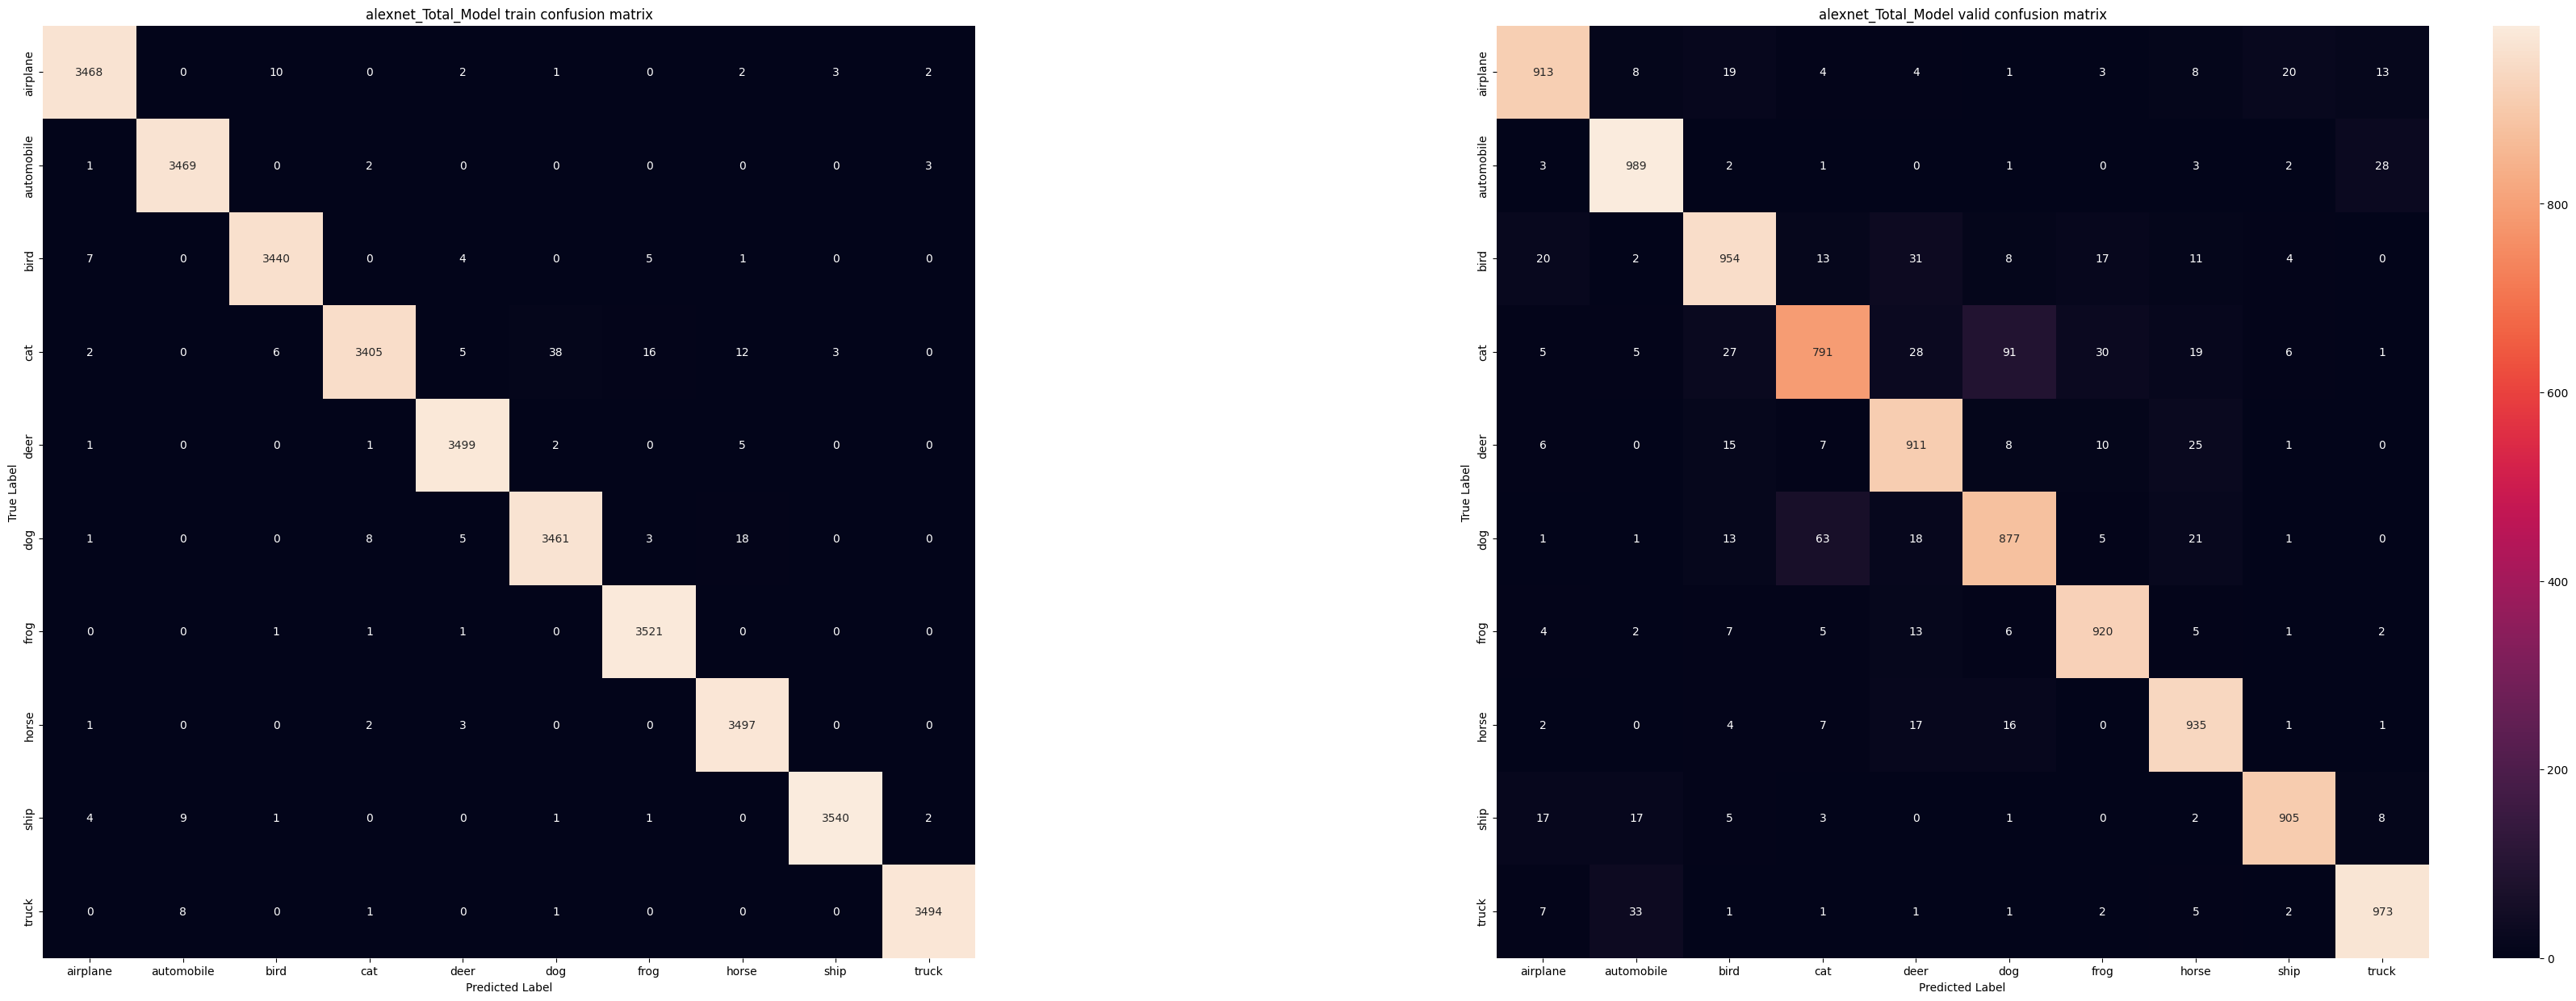

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

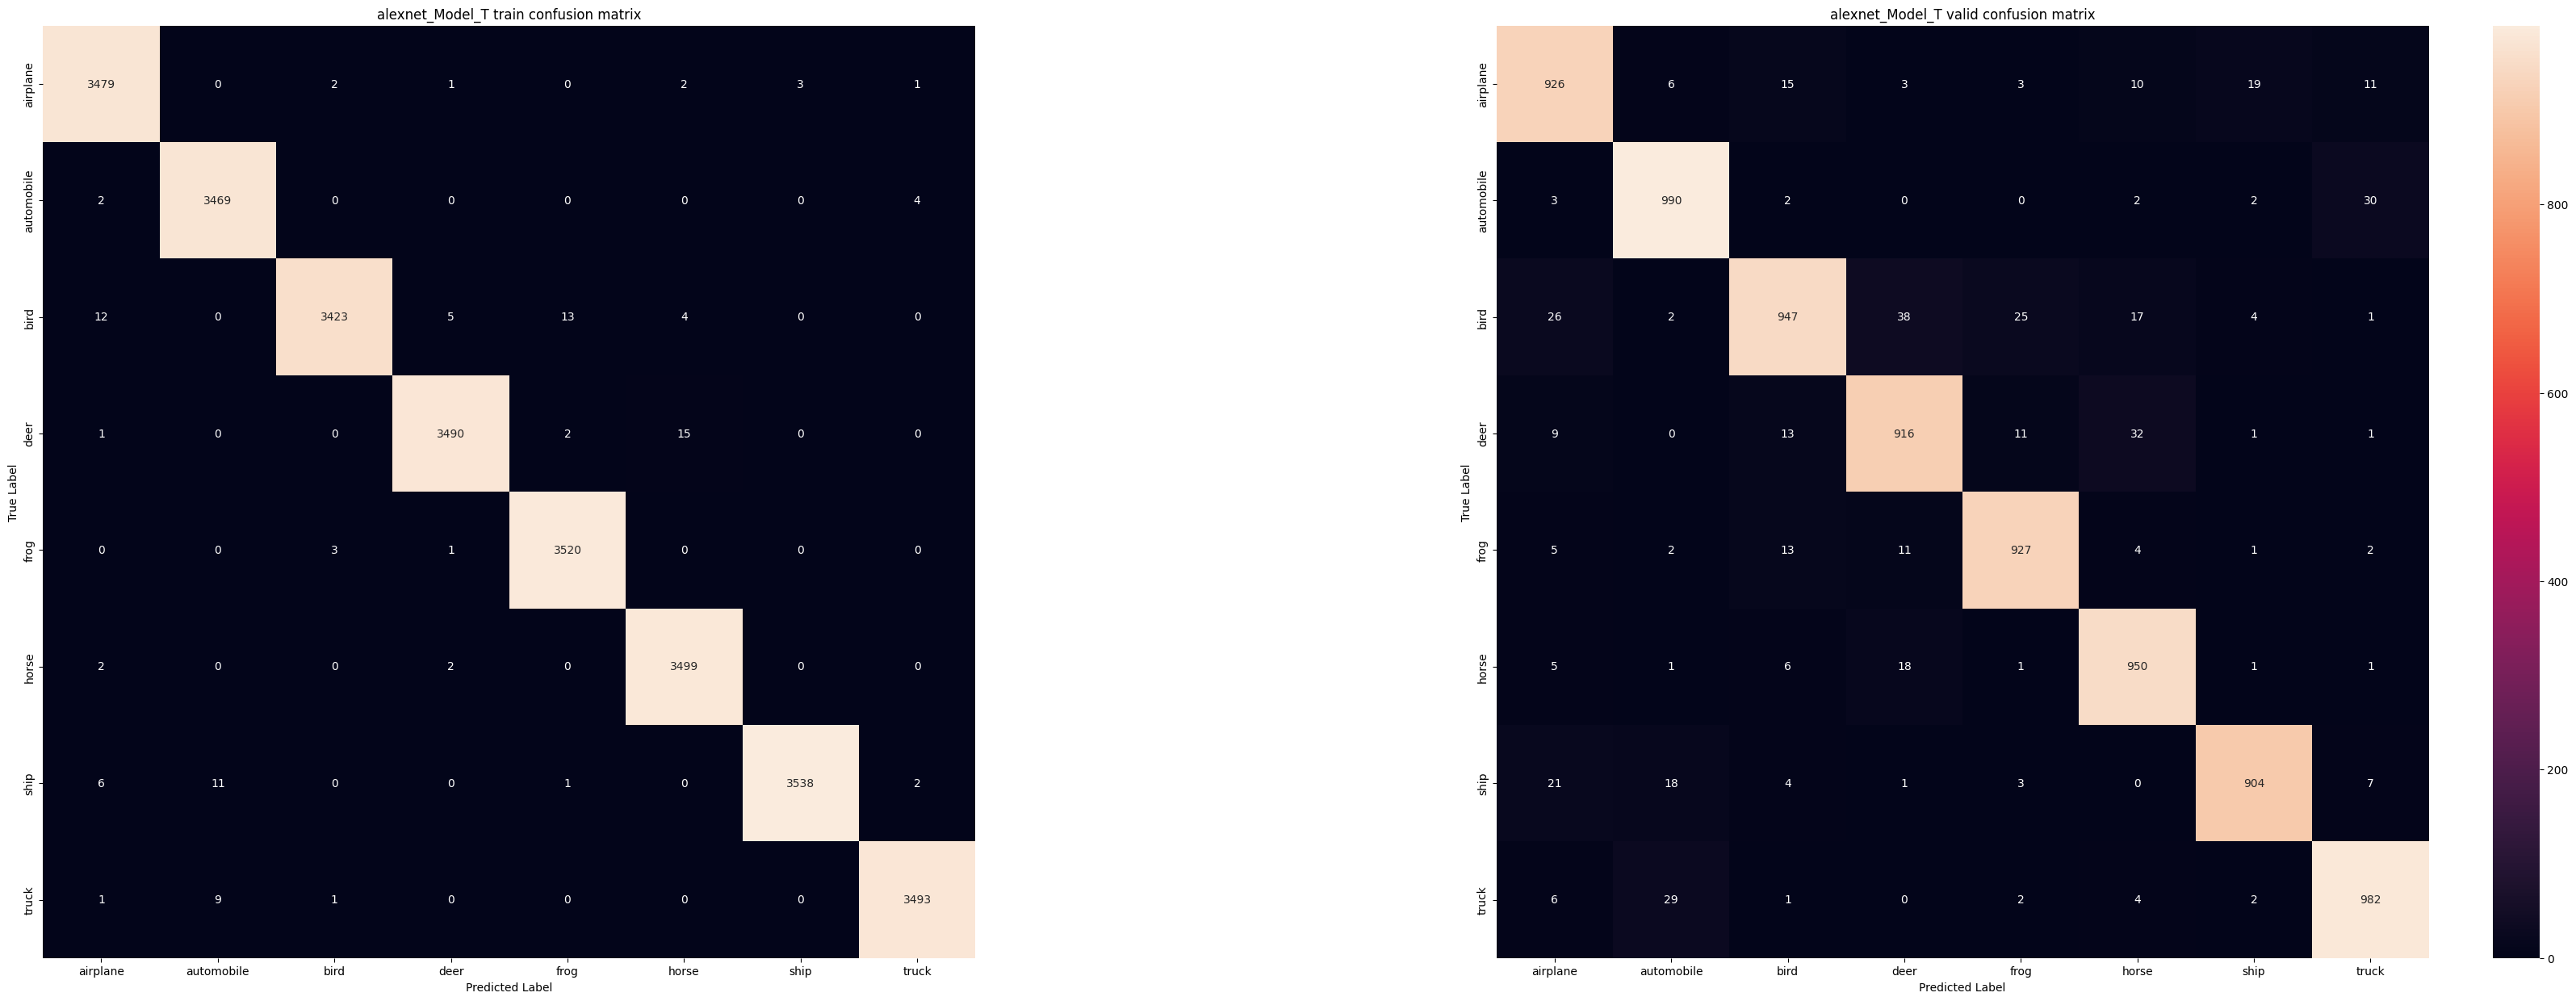

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

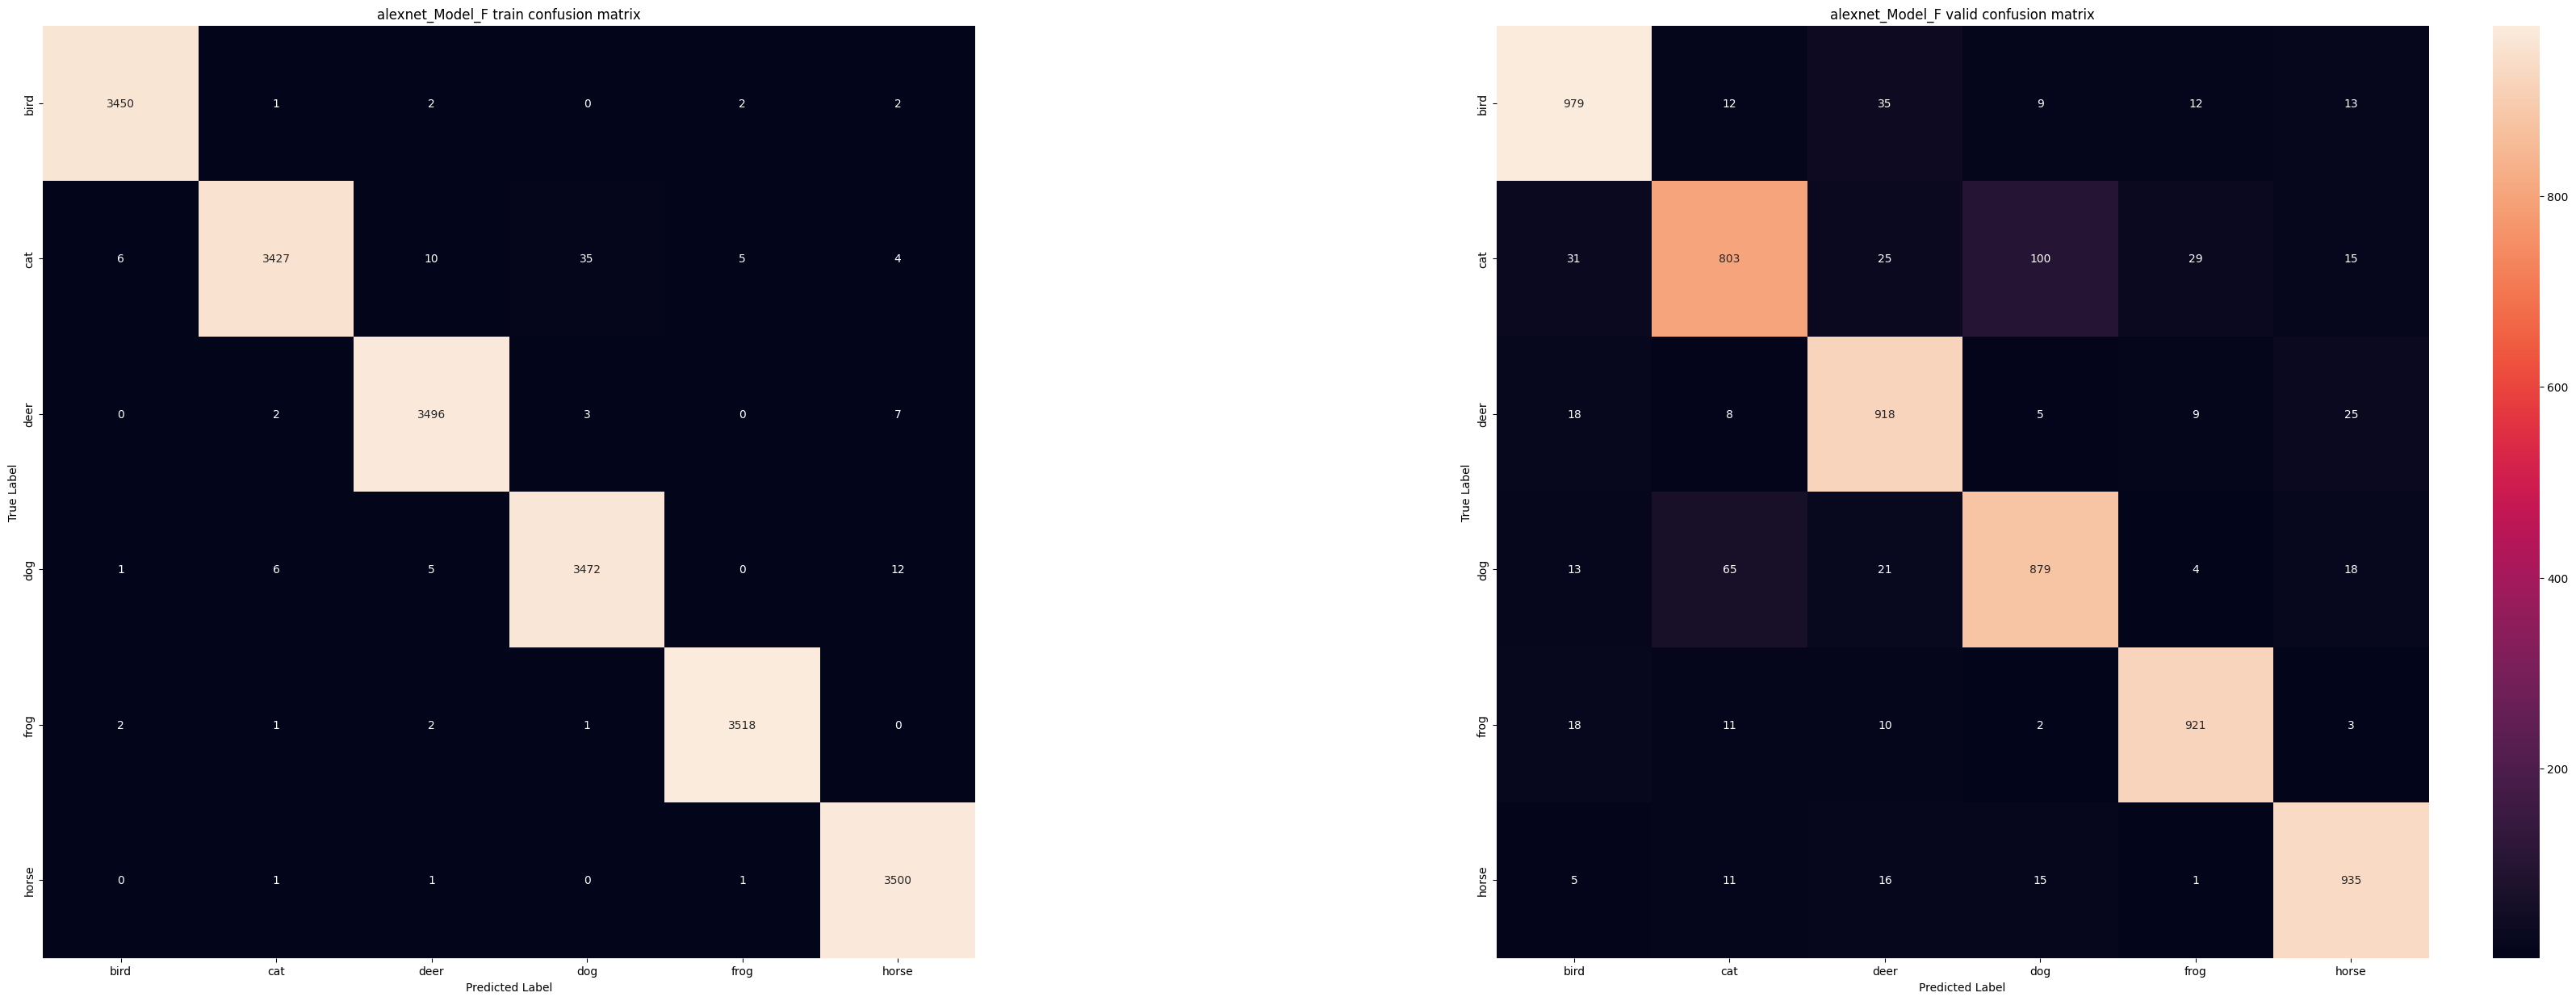

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,35161,2,2,2,2,1.000000,1.000000,1.000000,1.000000,True,True,True,False,False
1,11875,6,6,6,6,1.000000,1.000000,0.999993,1.000000,True,True,True,True,True
2,29939,4,4,4,4,0.999998,1.000000,0.999953,1.000000,True,True,True,False,False
3,47448,9,7,9,9,0.963882,1.000000,0.999999,1.000000,False,True,True,True,True
4,18076,8,2,8,8,0.999554,1.000000,1.000000,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,40047,6,6,6,6,0.999999,1.000000,0.999923,0.999995,True,True,True,True,True
34996,19085,7,7,7,7,0.967411,0.999978,0.993502,0.989327,True,True,True,True,True
34997,30089,6,6,6,6,1.000000,1.000000,0.999959,1.000000,True,True,True,True,True
34998,36496,2,2,2,2,0.999853,0.995022,0.953841,0.999932,True,True,True,False,False


In [49]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
99,27049,2,2,2,6,0.673477,0.897261,0.579256,0.656306,True,True,False,True,False
277,8242,0,4,0,4,0.999347,0.999915,0.894378,0.900834,False,True,False,False,True
505,23196,7,7,7,4,0.620979,0.999213,0.545204,0.838694,True,True,False,False,True
665,44756,5,5,7,5,0.586511,0.667728,0.559590,0.601949,True,False,True,True,False
705,21794,4,4,4,7,0.936979,0.847926,0.527969,0.710376,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34427,338,7,7,7,7,0.982468,0.995040,0.589838,0.580634,True,True,True,False,True
34499,3991,6,6,6,2,0.674215,0.928385,0.901547,0.767201,True,True,False,False,True
34710,12043,2,2,2,6,0.989133,0.787571,0.754980,0.676125,True,True,False,True,False
34905,26820,7,7,7,5,0.583546,0.944074,0.500345,0.778164,True,True,False,False,True


In [50]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

2    43
4    34
7    32
3    27
6    26
0    21
5    12
9     3
8     3
Name: Target, dtype: int64

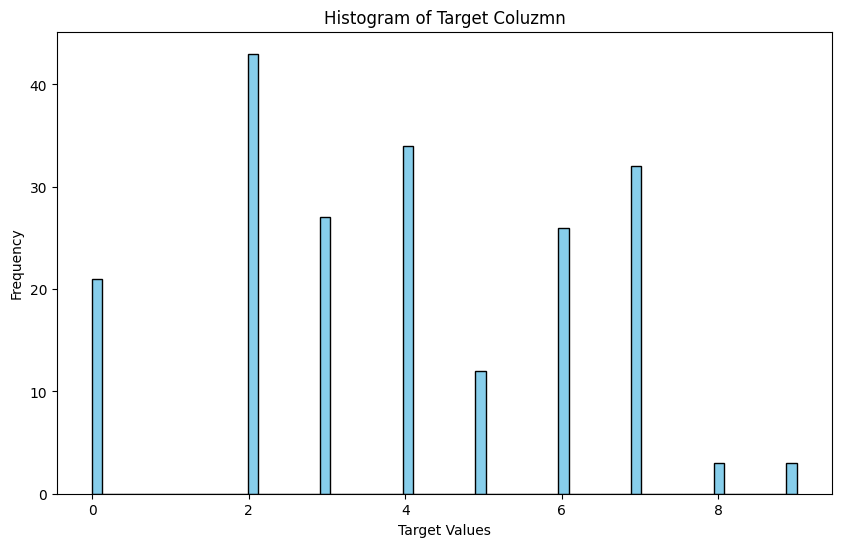

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [52]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,40407,1,6,1,1,0.998176,0.999981,0.997987,1.000000,False,True,True,True,True
1,6844,4,4,4,4,1.000000,1.000000,0.999998,0.999998,True,True,True,False,False
2,23180,6,6,6,6,0.999994,1.000000,0.999981,1.000000,True,True,True,True,True
3,156,5,5,4,5,0.951016,0.921843,0.973449,0.999998,True,False,True,False,False
4,35808,8,2,8,8,0.976265,1.000000,1.000000,0.999999,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,41424,8,2,8,8,0.908720,1.000000,0.999999,1.000000,False,True,True,True,True
9996,37031,9,7,9,9,0.421198,0.999977,0.999866,0.999865,False,True,True,True,True
9997,11896,1,3,1,1,0.576526,0.996756,0.996299,1.000000,False,True,True,True,True
9998,2822,6,6,6,3,0.492919,0.998198,0.515817,0.854505,True,True,False,False,True


In [53]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
14,17633,0,2,0,4,0.945693,0.977458,0.723190,0.984859,False,True,False,False,True
45,19944,2,2,2,8,0.998800,0.598807,0.517588,0.757307,True,True,False,True,False
59,29541,2,6,6,6,0.822210,0.998366,0.874571,0.937433,False,False,False,True,False
65,29561,3,3,1,9,0.795998,0.928864,0.362019,0.999518,True,False,False,True,False
100,28323,8,5,8,5,0.727955,0.486574,0.419292,0.823324,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9947,15020,7,4,4,4,0.449941,0.551191,0.466794,0.846924,False,False,False,False,True
9954,42332,0,2,0,2,0.999706,0.827296,0.643245,0.744460,False,True,False,False,True
9964,47413,3,6,6,6,0.653932,0.857028,0.567025,0.680486,False,False,False,True,False
9986,23191,4,6,6,6,0.983351,0.999585,0.650326,0.982045,False,False,False,True,False


In [54]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

3    60
7    55
2    51
6    47
4    44
0    31
5    21
8     8
9     4
1     4
Name: Target, dtype: int64

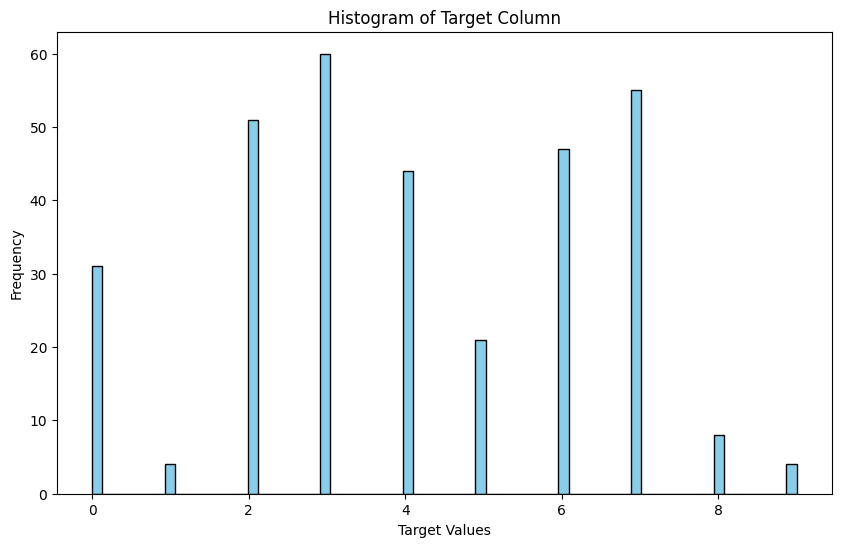

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [57]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.07752960193295563, 0.9923142857142857, 13828, 21172)

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.5928782888934017, 0.91, 3928, 6072)

In [59]:
ALL=set(range(10))
targetT=list(ALL-set(targetF))

model_0_embed= copy.deepcopy(model_0)
# model_0_embed.classifier[5]=nn.Identity()
model_0_embed.classifier[6]=nn.Identity()

In [60]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [61]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [62]:
mean_features_F

{3: tensor([0.0012, 0.1312, 0.0000,  ..., 0.2597, 0.0146, 0.0008]),
 5: tensor([3.0362e-04, 2.2431e-01, 0.0000e+00,  ..., 6.9865e-01, 1.0215e-02,
         0.0000e+00]),
 2: tensor([1.1921e-03, 1.3220e-01, 0.0000e+00,  ..., 9.2877e-03, 3.2576e-02,
         8.4251e-05]),
 4: tensor([6.2054e-04, 4.1122e-04, 0.0000e+00,  ..., 4.8829e-03, 5.5587e-03,
         2.5494e-05])}

In [63]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [64]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/train_size
sum_all

0.9845142857142857

In [65]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/valid_size
sum_all

0.9593

In [66]:
#全部模型裝在一起的表現
def total_model_cos_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
                k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)

                if(similarity_T>similarity_F):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [67]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.10494180971642823, 0.9897142857142858, 13701, 21299)

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.4668956494912505, 0.9136, 3930, 6070)

In [69]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [70]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [71]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [72]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [73]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.08524513160686141, 0.9916285714285714, 13810, 21190)

In [74]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.48914290733635424, 0.9136, 3946, 6054)

In [75]:
# 计算并打印每个数据点的平均边际效应
def calculate_ame_per_sample(model, data_loader, delta=1e-5):
    model.eval()
    ames = []
    idxs=[]
    with torch.no_grad():
        for inputs, _,idx in data_loader:
            inputs = inputs.to(device)
            base_preds = model(inputs).cpu().numpy()

            batch_ames = []
            
            for i in range(inputs.shape[1]):  # 对每个通道计算边际效应
                inputs_delta = inputs.clone()
                inputs_delta[:, i, :, :] += delta
                delta_preds = model(inputs_delta).cpu().numpy()
                ame = (delta_preds - base_preds) / delta
                batch_ames.append(ame)

            batch_ames = np.stack(batch_ames, axis=1)  # (batch_size, num_channels, num_classes)
            batch_ames = np.mean(batch_ames, axis=(1, 2))
            
            ames.append(batch_ames)
            idxs.extend(idx.cpu().numpy())

    ames = np.concatenate(ames, axis=0)  # (num_samples, num_channels, num_classes)
    return idxs,ames



In [76]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_F, Fdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.95 # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Fdataset = Subset(images, filter_idxs)
filtered_Fdl= DataLoader(filtered_Fdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.06655163657431333,train_accu=0.979223125564589
Epoch=0,valid_loss=0.31447369330349784,valid_accu=0.9000667334000667
0
Epoch=1,train_loss=0.047813551043331605,train_accu=0.9862491217504767
Epoch=1,valid_loss=0.30823876365645103,valid_accu=0.9055722389055723
0
Epoch=2,train_loss=0.04192116933666423,train_accu=0.9876041353006123
Epoch=2,valid_loss=0.34581037202317355,valid_accu=0.8967300633967301
Epoch=3,train_loss=0.02610508715855875,train_accu=0.9922212185084813
Epoch=3,valid_loss=0.3593723580184025,valid_accu=0.9000667334000667
Epoch=4,train_loss=0.0180038632724528,train_accu=0.9948308742346683
Epoch=4,valid_loss=0.3506760778906825,valid_accu=0.9060727394060727
0
Epoch=5,train_loss=0.013020904919466869,train_accu=0.9969386730904346
Epoch=5,valid_loss=0.37392207386123166,valid_accu=0.9062395729062396
0
Epoch=6,train_loss=0.009984635986811607,train_accu=0.998193315266486
Epoch=6,valid_loss=0.37462277161557206,valid_accu=0.9054054054054054
Epoch=7,train_loss=0.0088091

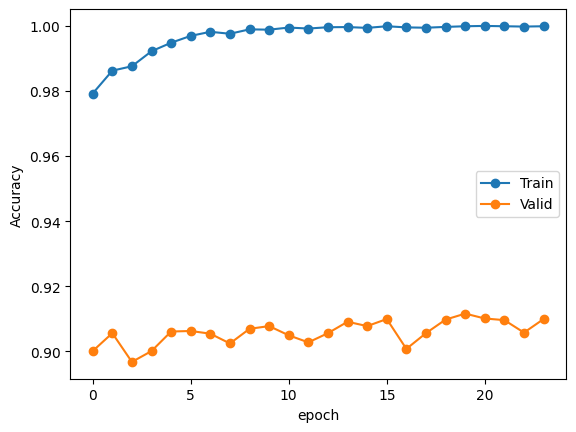

In [77]:
model_F_filter=model_train(model_algo,filtered_Fdl,Fdl_v,"F_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [78]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_T, Tdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.9  # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Tdataset = Subset(images, filter_idxs)
filtered_Tdl= DataLoader(filtered_Tdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.03371673055117255,train_accu=0.9894507237755304
Epoch=0,valid_loss=0.19459132017441746,valid_accu=0.9391021633112417
0
Epoch=1,train_loss=0.028060460057450876,train_accu=0.9907991275034702
Epoch=1,valid_loss=0.21382216650121985,valid_accu=0.9393522570964111
0
Epoch=2,train_loss=0.014106770800222535,train_accu=0.9961134245488796
Epoch=2,valid_loss=0.20872389990405485,valid_accu=0.9447292734775541
0
Epoch=3,train_loss=0.013041514178798756,train_accu=0.9956771762839579
Epoch=3,valid_loss=0.2178346057120481,valid_accu=0.9407277729148431
Epoch=4,train_loss=0.011275982463020619,train_accu=0.9966289906801507
Epoch=4,valid_loss=0.2466968354225537,valid_accu=0.9424784294110291
Epoch=5,train_loss=0.006607421778631198,train_accu=0.998294665873488
Epoch=5,valid_loss=0.2301034145214421,valid_accu=0.9438539452294611
Epoch=6,train_loss=0.005778665011583848,train_accu=0.998294665873488
Epoch=6,valid_loss=0.2648628554743063,valid_accu=0.9432287107665375
4 Early stopping!


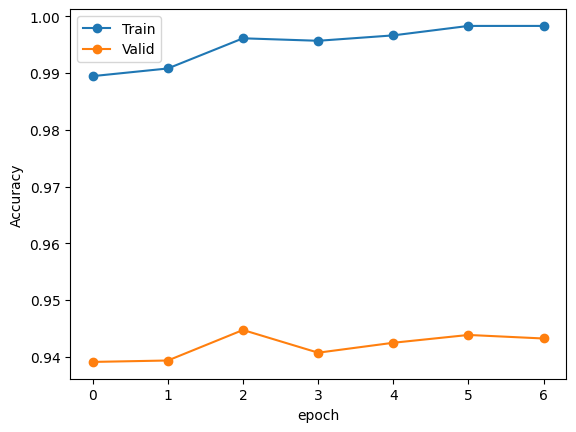

In [79]:
model_T_filter=model_train(model_algo,filtered_Tdl,Tdl_v,"T_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [80]:
F_loss_f,F_accu_f,confusion_matrix_F_train_f=evaluate_model(model_F_filter,Fdl,len(Fdataset),'F',mode='eval')
F_valid_loss_f,F_valid_accu_f,confusion_matrix_F_valid_f=evaluate_model(model_F_filter,Fdl_v,len(Fdataset_v),'F',mode='eval')

In [81]:
T_loss_f,T_accu_f,confusion_matrix_T_train_f=evaluate_model(model_T_filter,Tdl,len(Tdataset),'T',mode='eval')
T_valid_loss_f,T_valid_accu_f,confusion_matrix_T_valid_f=evaluate_model(model_T_filter,Tdl_v,len(Tdataset_v),'T',mode='eval')

In [82]:
total_train_loss_f,total_train_accu_f,confusion_matrix_total_train_f,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T_filter,model_F_filter,model_decision)
total_valid_loss_f,total_valid_accu_f,confusion_matrix_total_valid_f,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T_filter,model_F_filter,model_decision)

In [83]:
train_losses=[train_loss,decision_loss,T_loss_f,F_loss_f,total_train_loss_f,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu_f,F_accu_f,total_train_accu_f,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss_f,F_valid_loss_f,total_valid_loss_f,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu_f,F_valid_accu_f,total_valid_accu_f,total_valid_accu_d]

In [84]:
model_algos=['Model_0','Model_Decision',"Model_T_f","Model_F_f","Total_Model_f",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.086968,0.973257,0.293903,0.904000
1,Model_Decision,0.018603,0.994657,0.093075,0.970700
2,Model_T_f,0.014291,0.995860,0.206756,0.946105
3,Model_F_f,0.001774,0.999619,0.474179,0.912079
4,Total_Model_f,0.047714,0.995629,0.544313,0.915800
5,Total_Model_without_decision,0.017975,0.995200,0.273763,0.923700
